# 01 — MDP Formulation
**Week 3 | RL Fundamentals**

A **Markov Decision Process** (MDP) is defined by the 5-tuple:

$$M = (\mathcal{S},\; \mathcal{A},\; \mathcal{R},\; \mathcal{T},\; \gamma)$$

| Symbol | Meaning |
|---|---|
| S | State space |
| A | Action space |
| R(s,a,s') | Reward function |
| T(s,a,s') | Transition function P(s'|s,a) |
| γ ∈ [0,1) | Discount factor |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. Constructing a Tiny MDP by Hand
A recycling robot (from Sutton & Barto, Example 3.3):  
- **States**: {high battery, low battery}  
- **Actions**: {search, wait, recharge}  
- **Goal**: maximise cans collected

In [2]:
# States
S = ['high', 'low']
s_idx = {s: i for i, s in enumerate(S)}

# Actions (not all available in every state but we'll handle that via masks)
A = ['search', 'wait', 'recharge']
a_idx = {a: i for i, a in enumerate(A)}

# Transition tensor: T[s, a, s'] = P(s'|s,a)
# and Reward matrix:  R[s, a] = expected reward
alpha = 0.9   # P(stay high | high, search)
beta  = 0.4   # P(stay low  | low,  search)
r_search_high = 4.0
r_search_low  = 2.0
r_wait        = 1.0

T = np.zeros((2, 3, 2))   # (states, actions, next_states)
R = np.full((2, 3), -np.inf)  # -inf for illegal actions

# From HIGH
T[0, 0, 0] = alpha;    T[0, 0, 1] = 1 - alpha;  R[0, 0] = r_search_high  # search
T[0, 1, 0] = 1.0;                                R[0, 1] = r_wait         # wait
# recharge not available from high

# From LOW
T[1, 0, 0] = 1-beta;   T[1, 0, 1] = beta;        R[1, 0] = r_search_low   # search
T[1, 1, 1] = 1.0;                                 R[1, 1] = r_wait         # wait
T[1, 2, 0] = 1.0;                                 R[1, 2] = 0.0            # recharge

print("Transition tensor shape:", T.shape, "  (states × actions × next_states)")
print("\nReward matrix R[s,a]:")
for i, s in enumerate(S):
    for j, a in enumerate(A):
        r = R[i, j]
        print(f"  R[{s},{a}] = {r if r != -np.inf else 'N/A'}")

Transition tensor shape: (2, 3, 2)   (states × actions × next_states)

Reward matrix R[s,a]:
  R[high,search] = 4.0
  R[high,wait] = 1.0
  R[high,recharge] = N/A
  R[low,search] = 2.0
  R[low,wait] = 1.0
  R[low,recharge] = 0.0


## 2. Simulate One Episode Under a Random Policy

In [3]:
def valid_actions(s):
    if s == 0:  return [0, 1]        # high: search, wait
    else:       return [0, 1, 2]     # low:  search, wait, recharge

def step(s, a):
    next_s = np.random.choice(2, p=T[s, a])
    r = R[s, a]
    return next_s, r

def simulate_episode(start=0, n_steps=20, gamma=0.95):
    s = start
    trajectory = []
    for t in range(n_steps):
        a = np.random.choice(valid_actions(s))
        next_s, r = step(s, a)
        trajectory.append({'t': t, 'state': S[s], 'action': A[a], 'reward': r, 'next': S[next_s]})
        s = next_s
    return trajectory

traj = simulate_episode()
print(f"{'t':>3}  {'State':<8} {'Action':<10} {'Reward':>7}  {'Next':>8}")
print("-" * 45)
for step_ in traj[:10]:
    print(f"{step_['t']:>3}  {step_['state']:<8} {step_['action']:<10} {step_['reward']:>7.1f}  {step_['next']:>8}")

  t  State    Action      Reward      Next
---------------------------------------------
  0  high     search         4.0      high
  1  high     search         4.0      high
  2  high     wait           1.0      high
  3  high     wait           1.0      high
  4  high     search         4.0      high
  5  high     search         4.0       low
  6  low      recharge       0.0      high
  7  high     wait           1.0      high
  8  high     search         4.0      high
  9  high     wait           1.0      high


## 3. Real-World MDP Formulations
Practice framing problems as MDPs before coding them.

In [4]:
problems = {
    "Taxi Driver": {
        "States":   "(row, col, passenger_loc, destination) — 500 states",
        "Actions":  "N, S, E, W, Pickup, Dropoff",
        "Reward":   "-1 per step, +20 for delivery, -10 illegal pickup/dropoff",
        "Terminal": "After successful dropoff",
        "gamma":    0.99,
    },
    "CartPole": {
        "States":   "(cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4",
        "Actions":  "Push left (0) or Push right (1)",
        "Reward":   "+1 for every timestep the pole stays upright",
        "Terminal": "Pole falls >15° or cart moves >2.4 from centre",
        "gamma":    1.0,
    },
    "Trading Agent": {
        "States":   "(price_history, holdings, cash, technical_indicators)",
        "Actions":  "Buy / Sell / Hold (continuous or discrete)",
        "Reward":   "Change in portfolio value or Sharpe ratio",
        "Terminal": "End of trading day / time horizon reached",
        "gamma":    0.99,
    },
}

for name, mdp in problems.items():
    print(f"\n=== {name} ===")
    for k, v in mdp.items():
        print(f"  {k:<10}: {v}")


=== Taxi Driver ===
  States    : (row, col, passenger_loc, destination) — 500 states
  Actions   : N, S, E, W, Pickup, Dropoff
  Reward    : -1 per step, +20 for delivery, -10 illegal pickup/dropoff
  Terminal  : After successful dropoff
  gamma     : 0.99

=== CartPole ===
  States    : (cart_pos, cart_vel, pole_angle, pole_vel) — continuous R^4
  Actions   : Push left (0) or Push right (1)
  Reward    : +1 for every timestep the pole stays upright
  Terminal  : Pole falls >15° or cart moves >2.4 from centre
  gamma     : 1.0

=== Trading Agent ===
  States    : (price_history, holdings, cash, technical_indicators)
  Actions   : Buy / Sell / Hold (continuous or discrete)
  Reward    : Change in portfolio value or Sharpe ratio
  Terminal  : End of trading day / time horizon reached
  gamma     : 0.99


## ✅ Exercises
1. Formalise a **Frozen Lake 4×4** as an MDP. How many states? How many actions? What are the terminal states?
2. Pick a board game you know (noughts & crosses, connect 4). Define S, A, R, and T for it.
3. **Challenge**: simulate 1000 episodes of the recycling robot under the policy 'always search'. Plot the distribution of total undiscounted reward per episode.

EXERCISE 1 — Frozen Lake 4×4
States   : 16  (4×4 grid, indices 0–15)
Actions  : 4  (Left, Down, Right, Up)
Terminal : holes [5, 7, 11, 12]  +  goal [15]
T shape  : (16, 4, 16)   (verify rows sum to 1)
Row-sum check (first 4 states): [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


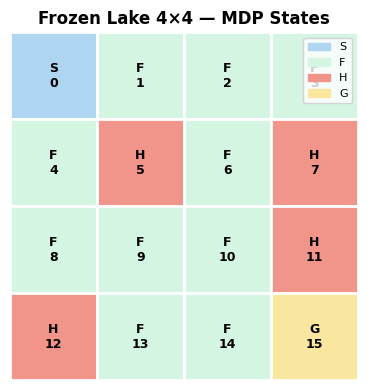


EXERCISE 2 — Tic-Tac-Toe
States   : 5478 legal board configurations
Terminal : 958 (wins + draws)
Actions  : up to 9 (only empty squares; shrinks each turn)
Reward   : +1 win | -1 loss | 0 draw
gamma    : 1.0  (episodic, finite horizon)

Random vs Random (10 000 episodes):
  X_win   :  5887  (58.9%)
  O_win   :  2833  (28.3%)
  Draw    :  1280  (12.8%)


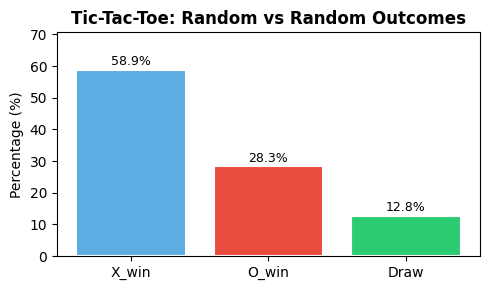


EXERCISE 3 — Recycling Robot: Always-Search Policy
  always_search     mean=74.86  std=4.08  min=56.0  max=80.0
  always_wait       mean=20.00  std=0.00  min=20.0  max=20.0
  random            mean=47.46  std=6.62  min=26.0  max=67.0


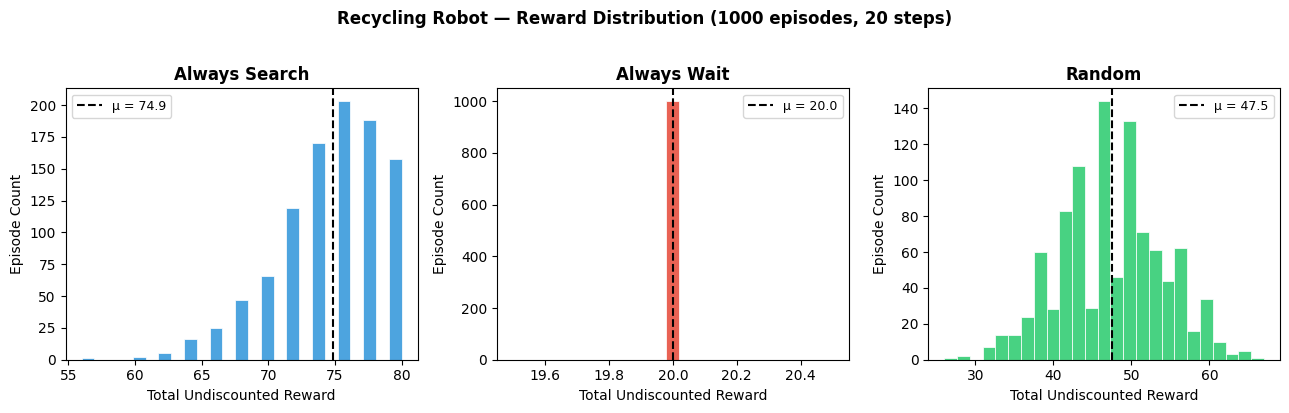


Fraction of time in 'high' battery state:
  always_search     0.866
  always_wait       1.000
  random            0.923


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)

# ============================================================
# EXERCISE 1 — Frozen Lake 4×4 as an MDP
# ============================================================
print("=" * 60)
print("EXERCISE 1 — Frozen Lake 4×4")
print("=" * 60)

# Grid layout (0=Frozen, H=Hole, G=Goal)
GRID = [
    'S', 'F', 'F', 'F',
    'F', 'H', 'F', 'H',
    'F', 'F', 'F', 'H',
    'H', 'F', 'F', 'G',
]
n_states  = 16
n_actions = 4   # 0=Left, 1=Down, 2=Right, 3=Up
ACTION_NAMES = ['Left', 'Down', 'Right', 'Up']
HOLES    = {5, 7, 11, 12}
GOAL     = {15}
TERMINAL = HOLES | GOAL

# Slippery transitions: intended action with p=1/3,
# two perpendicular directions with p=1/3 each.
# Perpendicular map: for each action, the two side-slip actions
PERP = {0: [1, 3], 1: [0, 2], 2: [1, 3], 3: [0, 2]}

def move(s, a):
    """Return next state after taking action a from state s (no slip)."""
    row, col = s // 4, s % 4
    if   a == 0: col -= 1   # Left
    elif a == 1: row += 1   # Down
    elif a == 2: col += 1   # Right
    elif a == 3: row -= 1   # Up
    row = max(0, min(3, row))
    col = max(0, min(3, col))
    return row * 4 + col

# Build transition tensor T_fl[s, a, s'] and reward matrix R_fl[s, a]
T_fl = np.zeros((n_states, n_actions, n_states))
R_fl = np.zeros((n_states, n_actions))

for s in range(n_states):
    if s in TERMINAL:
        # Absorbing — stay in place with prob 1
        T_fl[s, :, s] = 1.0
        continue
    for a in range(n_actions):
        for slip_a, prob in [(a, 1/3)] + [(p, 1/3) for p in PERP[a]]:
            ns = move(s, slip_a)
            T_fl[s, a, ns] += prob
        # Reward: +1 only if the intended transition lands on goal
        R_fl[s, a] = 1.0 if move(s, a) == 15 else 0.0

print(f"States   : {n_states}  (4×4 grid, indices 0–15)")
print(f"Actions  : {n_actions}  ({', '.join(ACTION_NAMES)})")
print(f"Terminal : holes {sorted(HOLES)}  +  goal {sorted(GOAL)}")
print(f"T shape  : {T_fl.shape}   (verify rows sum to 1)")
print(f"Row-sum check (first 4 states): {T_fl[:4].sum(axis=2)}")

# Visualise the grid
fig, ax = plt.subplots(figsize=(4, 4))
colors = {'S': '#aed6f1', 'F': '#d5f5e3', 'H': '#f1948a', 'G': '#f9e79f'}
for i, cell in enumerate(GRID):
    r, c = i // 4, i % 4
    ax.add_patch(plt.Rectangle((c, 3-r), 1, 1,
                                color=colors[cell], ec='white', lw=2))
    ax.text(c + 0.5, 3 - r + 0.5, f"{cell}\n{i}",
            ha='center', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_aspect('equal')
ax.axis('off'); ax.set_title("Frozen Lake 4×4 — MDP States", fontweight='bold')
legend = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig("ex1_frozen_lake.png", dpi=120)
plt.show()
print()


# ============================================================
# EXERCISE 2 — Tic-Tac-Toe as an MDP
# ============================================================
print("=" * 60)
print("EXERCISE 2 — Tic-Tac-Toe")
print("=" * 60)

# Board: tuple of 9 ints (0=empty, 1=X, 2=O)
# Agent plays X (player 1); opponent plays O (player 2).

WINS = [
    (0,1,2),(3,4,5),(6,7,8),   # rows
    (0,3,6),(1,4,7),(2,5,8),   # cols
    (0,4,8),(2,4,6),           # diagonals
]

def check_winner(board):
    for (a, b, c) in WINS:
        if board[a] == board[b] == board[c] != 0:
            return board[a]   # 1 or 2
    return 0

def is_terminal(board):
    return check_winner(board) != 0 or 0 not in board

def reward(board, player=1):
    w = check_winner(board)
    if w == player:   return  1.0
    if w != 0:        return -1.0
    if 0 not in board: return  0.0   # draw
    return 0.0   # non-terminal

def valid_actions_ttt(board):
    return [i for i, v in enumerate(board) if v == 0]

def step_ttt(board, action, player=1):
    """Apply action for 'player', then a random opponent move."""
    b = list(board)
    b[action] = player
    b = tuple(b)
    if is_terminal(b):
        return b, reward(b, player)
    opp = 2 if player == 1 else 1
    opp_moves = valid_actions_ttt(b)
    opp_action = np.random.choice(opp_moves)
    b2 = list(b); b2[opp_action] = opp; b2 = tuple(b2)
    return b2, reward(b2, player)

# Count reachable states via BFS
from collections import deque

def count_states():
    visited = set()
    queue   = deque([(0,)*9])
    visited.add((0,)*9)
    terminal_count = 0
    while queue:
        board = queue.popleft()
        if is_terminal(board):
            terminal_count += 1
            continue
        # X moves next if #X == #O, else O moves
        xs = board.count(1); os = board.count(2)
        player = 1 if xs == os else 2
        for a in valid_actions_ttt(board):
            b = list(board); b[a] = player; b = tuple(b)
            if b not in visited:
                visited.add(b)
                queue.append(b)
    return len(visited), terminal_count

total_states, terminal_states = count_states()

print(f"States   : {total_states} legal board configurations")
print(f"Terminal : {terminal_states} (wins + draws)")
print(f"Actions  : up to 9 (only empty squares; shrinks each turn)")
print(f"Reward   : +1 win | -1 loss | 0 draw")
print(f"gamma    : 1.0  (episodic, finite horizon)")

# Simulate a few episodes under random vs random
def simulate_ttt(n_episodes=1000):
    results = {'X_win': 0, 'O_win': 0, 'Draw': 0}
    for _ in range(n_episodes):
        board = (0,)*9
        while not is_terminal(board):
            for player in [1, 2]:
                if is_terminal(board): break
                a = np.random.choice(valid_actions_ttt(board))
                b = list(board); b[a] = player; board = tuple(b)
        w = check_winner(board)
        if   w == 1: results['X_win'] += 1
        elif w == 2: results['O_win'] += 1
        else:        results['Draw']  += 1
    return results

results = simulate_ttt(10000)
print(f"\nRandom vs Random (10 000 episodes):")
for k, v in results.items():
    print(f"  {k:<8}: {v:>5}  ({v/100:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 3))
labels = list(results.keys())
vals   = [results[k]/100 for k in labels]
bars   = ax.bar(labels, vals, color=['#5dade2','#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.5)
ax.set_ylabel("Percentage (%)"); ax.set_title("Tic-Tac-Toe: Random vs Random Outcomes", fontweight='bold')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(vals) * 1.2)
plt.tight_layout()
plt.savefig("ex2_tictactoe.png", dpi=120)
plt.show()
print()


# ============================================================
# EXERCISE 3 — Recycling Robot: 1000 episodes, "always search"
# ============================================================
print("=" * 60)
print("EXERCISE 3 — Recycling Robot: Always-Search Policy")
print("=" * 60)

# --- Reuse the MDP from the notebook ---
S = ['high', 'low']
A = ['search', 'wait', 'recharge']

alpha_r = 0.9;  beta_r = 0.4
r_search_high = 4.0;  r_search_low = 2.0;  r_wait = 1.0

T_r = np.zeros((2, 3, 2))
R_r = np.full((2, 3), -np.inf)

T_r[0,0,0]=alpha_r; T_r[0,0,1]=1-alpha_r; R_r[0,0]=r_search_high
T_r[0,1,0]=1.0;                            R_r[0,1]=r_wait
T_r[1,0,0]=1-beta_r; T_r[1,0,1]=beta_r;   R_r[1,0]=r_search_low
T_r[1,1,1]=1.0;                            R_r[1,1]=r_wait
T_r[1,2,0]=1.0;                            R_r[1,2]=0.0

def valid_actions_r(s):
    return [0, 1] if s == 0 else [0, 1, 2]

def step_r(s, a):
    ns = np.random.choice(2, p=T_r[s, a])
    return ns, R_r[s, a]

def simulate_episode_r(start=0, n_steps=20, policy='always_search'):
    s = start
    total_reward = 0.0
    state_log = [s]
    for _ in range(n_steps):
        if   policy == 'always_search': a = 0
        elif policy == 'always_wait':   a = 1
        else: a = np.random.choice(valid_actions_r(s))
        ns, r = step_r(s, a)
        total_reward += r
        s = ns
        state_log.append(s)
    return total_reward, state_log

# Run 1000 episodes
n_episodes = 1000
n_steps    = 20

policies = ['always_search', 'always_wait', 'random']
policy_rewards = {}

for pol in policies:
    rewards = [simulate_episode_r(n_steps=n_steps, policy=pol)[0]
               for _ in range(n_episodes)]
    policy_rewards[pol] = np.array(rewards)
    m, s = np.mean(rewards), np.std(rewards)
    print(f"  {pol:<16}  mean={m:.2f}  std={s:.2f}  "
          f"min={np.min(rewards):.1f}  max={np.max(rewards):.1f}")

# --- Plot: overlaid histograms for all three policies ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
pal = {'always_search': '#3498db', 'always_wait': '#e74c3c', 'random': '#2ecc71'}
labels = {'always_search': 'Always Search', 'always_wait': 'Always Wait', 'random': 'Random'}

for ax, pol in zip(axes, policies):
    rewards = policy_rewards[pol]
    ax.hist(rewards, bins=25, color=pal[pol], edgecolor='white',
            linewidth=0.6, alpha=0.88)
    mean_r = np.mean(rewards)
    ax.axvline(mean_r, color='black', linestyle='--', linewidth=1.5,
               label=f'μ = {mean_r:.1f}')
    ax.set_title(labels[pol], fontweight='bold')
    ax.set_xlabel("Total Undiscounted Reward")
    ax.set_ylabel("Episode Count")
    ax.legend(fontsize=9)

fig.suptitle(f"Recycling Robot — Reward Distribution ({n_episodes} episodes, {n_steps} steps)",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("ex3_recycling_robot.png", dpi=120, bbox_inches='tight')
plt.show()

# --- Bonus: fraction of time spent in each state per policy ---
print("\nFraction of time in 'high' battery state:")
for pol in policies:
    high_fracs = []
    for _ in range(n_episodes):
        _, log = simulate_episode_r(n_steps=n_steps, policy=pol)
        high_fracs.append(log.count(0) / len(log))
    print(f"  {pol:<16}  {np.mean(high_fracs):.3f}")